# Drift Colab Demo

Minimal Colab demo for direct sample generation and visualization.

Default example:
- `init_from = hf://latent_L_sota`
- `class_ids = 95,22,88,108,386,296,483,698`

Reference names for the default 8 classes:
- `95` jacamar
- `22` bald eagle
- `88` macaw
- `108` sea anemone
- `386` African elephant
- `296` ice bear
- `483` castle
- `698` palace

In [1]:
#@title 1. Setup (run twice — restarts runtime after installing dependencies)
import os
from pathlib import Path

# ==========================================
# Clone Repository
# ==========================================
REPO_URL = "https://github.com/lambertae/drifting.git"
REPO_REF = "main"
REPO_DIR = Path("/content/drifting")

if not REPO_DIR.exists():
    print("Cloning repository...")
    get_ipython().system(f"git clone --branch {REPO_REF} --single-branch {REPO_URL} {REPO_DIR}")
else:
    print("Repository already cloned.")

if REPO_DIR.exists():
    get_ipython().run_line_magic("cd", str(REPO_DIR))
else:
    print("Error: Repository directory not found.")

# ==========================================
# Environment & Dependencies
# ==========================================
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("HF_ROOT", "/content/hf_cache")

NEEDS_RESTART = not Path("/content/.deps_installed").exists()
if NEEDS_RESTART:
    print("Installing dependencies — the runtime will automatically restart after this cell.")
    print("When it restarts, simply re-run this cell (it will skip installation the second time).")
    get_ipython().system("pip install -q -r requirements.txt")
    Path("/content/.deps_installed").touch()
    import IPython
    IPython.get_ipython().kernel.do_shutdown(True)
else:
    print("Dependencies already installed. Setup complete!")

Repository already cloned.
/content/drifting
Dependencies already installed. Setup complete!


In [2]:
#@title 2. Helpers

import math
import sys
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings(
    "ignore",
    message="Flax classes are deprecated"
)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from utils.env import HF_ROOT
from utils.init_util import load_generator_model_and_params
from utils.misc import prepare_rng
from utils.hsdp_util import set_global_mesh, get_global_mesh

# 关键：先初始化 TPU mesh
if jax.device_count() >= 1:
    set_global_mesh(hsdp_dim=1)
    print("Initialized mesh:", get_global_mesh())

MODEL_CACHE = {}

print(f"JAX devices: {jax.devices()}")


def parse_class_ids(text: str) -> list[int]:
    class_ids = [int(part.strip()) for part in text.split(",") if part.strip()]
    if not class_ids:
        raise ValueError("Provide at least one class index.")
    for class_id in class_ids:
        if not 0 <= class_id < 1000:
            raise ValueError(f"class id out of range: {class_id}")
    return class_ids


def _is_latent(metadata: dict) -> bool:
    model_cfg = metadata.get("model_config", {})
    return model_cfg.get("in_channels", 3) == 4


def _build_postprocess_fn(latent: bool):
    """Build postprocess fn without mesh/sharding dependencies."""
    if latent:
        from dataset.vae import vae_enc_decode
        _, decode_fn = vae_enc_decode(replicate_params=False)

        def postprocess(images):
            return jnp.clip((decode_fn(images) + 1) / 2, 0, 1)

        return postprocess

    def postprocess(images):
        return jnp.clip((images + 1) / 2, 0, 1).transpose(0, 3, 1, 2)

    return postprocess


def _generate_step(batch, params, rng, apply_fn, postprocess_fn, cfg_scale=1.0):
    _, labels = batch
    latent_samples = apply_fn(
        {"params": params},
        train=False,
        rngs=prepare_rng(rng, ["noise"]),
        c=labels,
        cfg_scale=cfg_scale,
    )["samples"]
    return postprocess_fn(latent_samples)


def load_pipeline(init_from: str):
    init_from = init_from.strip()
    if not init_from:
        raise ValueError("init_from is empty.")
    if init_from not in MODEL_CACHE:
        print(f"Loading model from {init_from} ...")
        model, params, metadata = load_generator_model_and_params(init_from, hf_cache_dir=HF_ROOT)
        latent = _is_latent(metadata)
        postprocess_fn = _build_postprocess_fn(latent)
        gen_step_jit = jax.jit(partial(_generate_step, apply_fn=model.apply, postprocess_fn=postprocess_fn))
        MODEL_CACHE[init_from] = (gen_step_jit, params, metadata)
    return MODEL_CACHE[init_from]


def generate_samples(gen_step_jit, params, *, class_ids: list[int], cfg_scale: float, seed: int) -> np.ndarray:
    labels = np.asarray(class_ids, dtype=np.int32)
    samples = []
    batch_size = min(4, len(labels))
    for start in range(0, len(labels), batch_size):
        batch_labels = labels[start : start + batch_size]
        batch = (np.zeros((len(batch_labels), 1), dtype=np.int32), batch_labels)
        out = gen_step_jit(
            batch,
            params=params,
            cfg_scale=cfg_scale,
            rng=jax.random.PRNGKey(seed + start),
        )
        samples.append(np.asarray(jax.device_get(out), dtype=np.float32))
    return np.concatenate(samples, axis=0)


def show_samples(samples: np.ndarray, class_ids: list[int]) -> None:
    images = np.asarray(samples)
    if images.shape[1] in (3, 4):
        images = images.transpose(0, 2, 3, 1)
    images = np.clip(images[..., :3], 0.0, 1.0)

    cols = min(4, len(images))
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).reshape(rows, cols)
    for idx, ax in enumerate(axes.flat):
        ax.axis("off")
        if idx >= len(images):
            continue
        ax.imshow(images[idx])
        ax.set_title(f"class {class_ids[idx]:03d}", fontsize=11)
    plt.tight_layout()
    plt.show()

Initialized mesh: Mesh('data': 1, 'fsdp': 1)
JAX devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


Loading model from hf://latent_L_sota ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

diffusion_flax_model.msgpack:   0%|          | 0.00/335M [00:00<?, ?B/s]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch cla

Generated samples: shape=(8, 3, 256, 256), dtype=float32
Model in_channels: 4


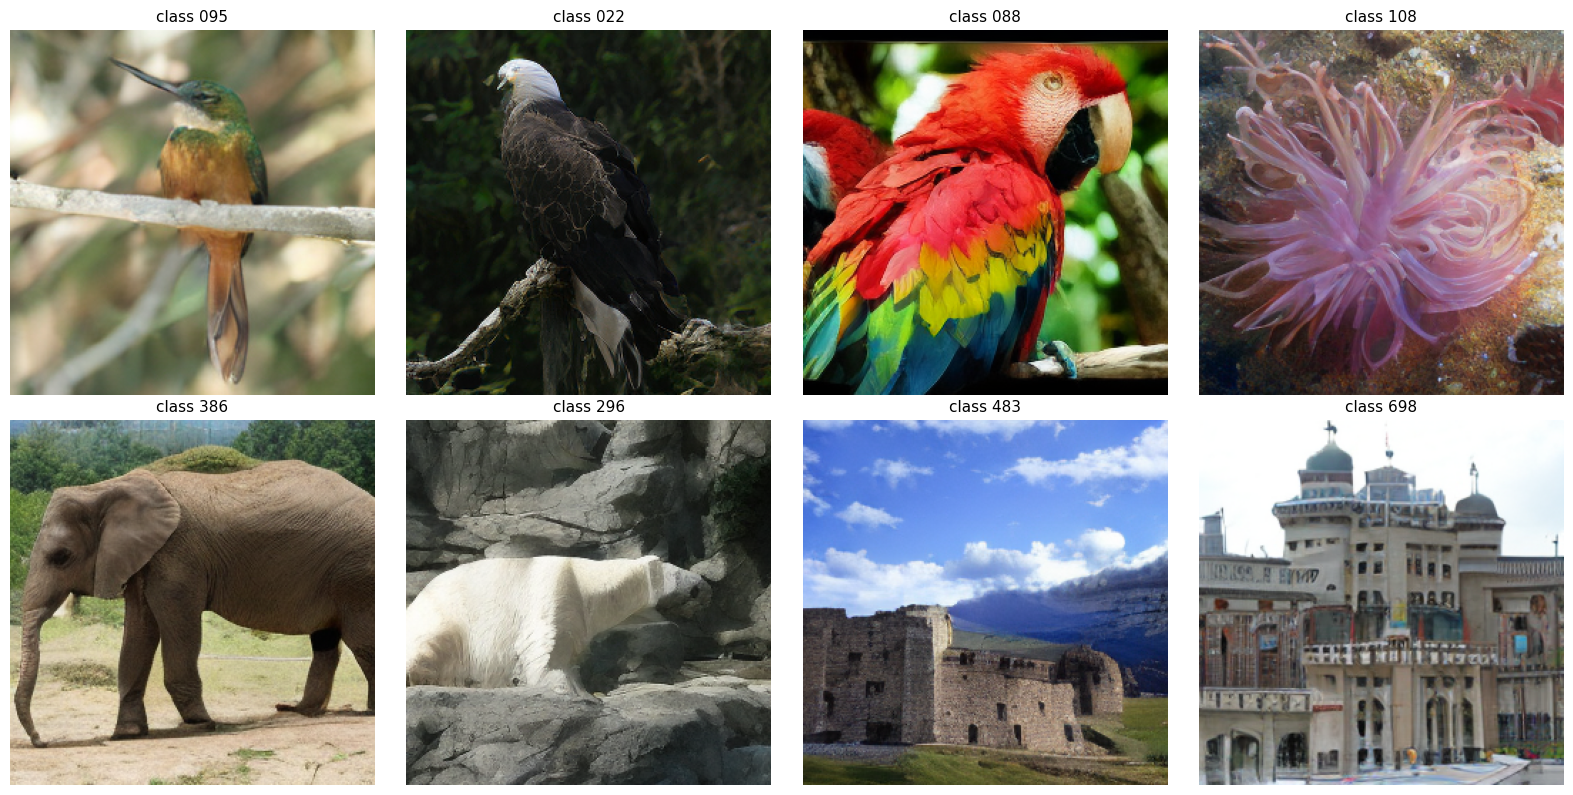

In [3]:
#@title 3. Generate
init_from = "hf://latent_L_sota" #@param {type:"string"}
class_ids_text = "95,22,88,108,386,296,483,698" #@param {type:"string"}
cfg_scale = 2.5 #@param {type:"number"}
seed = 0 #@param {type:"integer"}

class_ids = parse_class_ids(class_ids_text)
gen_step_jit, params, metadata = load_pipeline(init_from)
samples = generate_samples(
    gen_step_jit,
    params,
    class_ids=class_ids,
    cfg_scale=float(cfg_scale),
    seed=int(seed),
)
print(f"Generated samples: shape={samples.shape}, dtype={samples.dtype}")
print(f"Model in_channels: {metadata.get('model_config', {}).get('in_channels')}")
show_samples(samples, class_ids)
